## This is the code for "Waveguide based squeezed light sources in LiNbO_3 platform"

Author: Erik Anders Torsten Svanberg, Vaishali Adya.
Any errors found, please send to: esvanb@kth.se

References:
[1] Takahiro Kashiwazaki, Taichi Yamashima, Koji Enbutsu, Takushi Kazama, Asuka Inoue, Kosuke Fukui, Mamoru Endo, Takeshi Umeki, Akira Furusawa; Over-8-dB squeezed light generation by a broadband waveguide optical parametric amplifier toward fault-tolerant ultra-fast quantum computers. Appl. Phys. Lett. 5 June 2023; 122 (23): 234003. https://doi.org/10.1063/5.0144385

In [1]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sympy as sp

In [2]:
#Basic equations
def power2dB(power):
    #Convert power (linear scale) to dB
    return 10*np.log10(power)

def dB2power(dB):
    #Convert dB to power (linear scale)
    return 10**(dB/10)

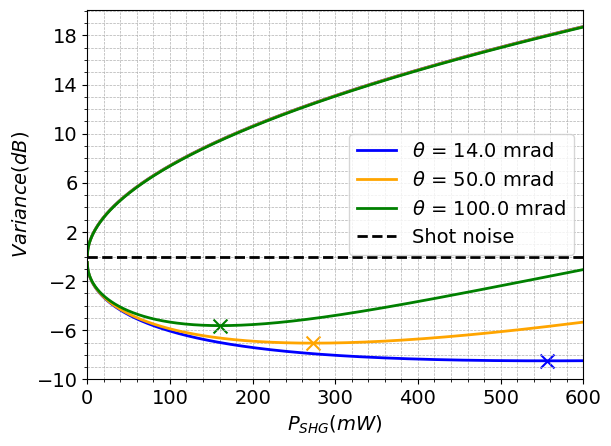

In [3]:
#Not included in paper, but useful for showing phase noise effects on squeezing
#Plot squeezing vs input power for different values of theta

def variance(P_in,alpha,eta,theta,theta_rms):
    #Calculate variance (squeezing and anti-squeezing) vs input power for given values of alpha, eta, theta, and theta_rms
    alpha = 8.2
    R = np.sqrt(P_in*alpha)
    return eta*(1-theta_rms**2)*(np.exp(2*R)*np.cos(theta)**2 + eta*np.exp(-2*R)*np.sin(theta)**2) + eta*theta_rms**2*(np.exp(-2*R)*np.cos(theta)**2 + eta*np.exp(2*R)*np.sin(theta)**2) + 1-eta

def plot_variance():
    #Plot variance (squeezing and anti-squeezing) vs input power for different values of theta
    alpha = 8.2
    P_in = np.linspace(0,0.6,1000)
    eta = 0.88
    theta_ls = [14e-3,50e-3,100e-3]
    color_ls = ['blue','orange','green']

    for theta_rms in theta_ls:
        sqz = variance(P_in,alpha,eta,np.pi/2,theta_rms)
        plt.plot(P_in*1e3,power2dB(sqz),color=color_ls[theta_ls.index(theta_rms)],linewidth=2,label=r'$\theta$ = '+str(theta_rms*1e3) + ' mrad')
        asqz = variance(P_in,alpha,eta,0,theta_rms)
        plt.plot(P_in*1e3,power2dB(asqz),color=color_ls[theta_ls.index(theta_rms)],linewidth=2)
        P_opt = 1/(4*alpha)*np.log(np.sqrt(theta_rms**2/(1-theta_rms**2)))**2
        #Mark optimal power for squeezing with an X
        plt.scatter(P_opt*1e3,power2dB(variance(P_opt,alpha,eta,np.pi/2, theta_rms)),color=color_ls[theta_ls.index(theta_rms)],marker='x',s=100)



    #Also label shot noise at y=0
    plt.axhline(0, color='black',linewidth=2,linestyle='--',label='Shot noise')
    plt.xlabel(r'$P_{SHG} (mW)$',fontsize=14)
    plt.ylabel(r'$Variance (dB)$',fontsize=14)
    #change yticks to go with 4 in steps
    plt.xticks(fontsize=14)
    plt.yticks(np.arange(-10,20,4),fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(which='both', linestyle='--', linewidth=0.5)
    plt.xlim(0,600)
    plt.minorticks_on()
    plt.show()

plot_variance()

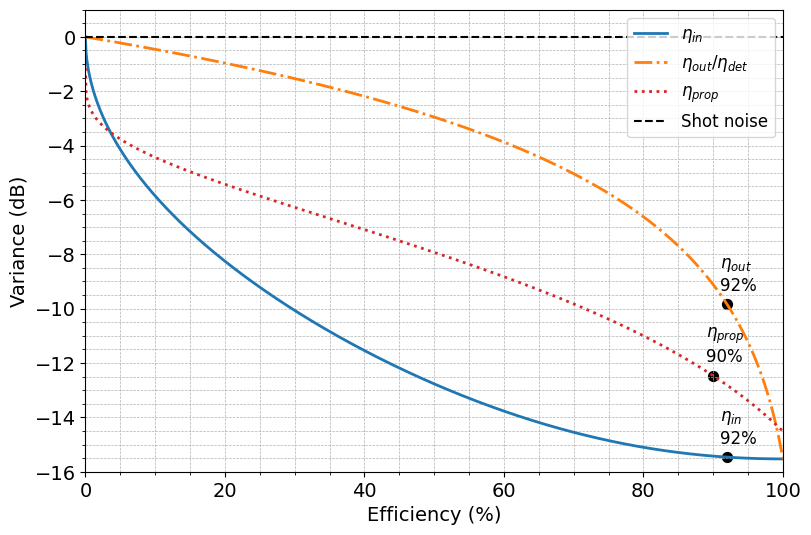

In [4]:
#Figure 2 
def four_panels():
    # Single plot showing squeezing for: eta_in (pump loss), eta_out (output/detection loss),
    # eta_det (detection — same functional dependence as eta_out), and eta_prop (propagation model).
    fontsize = 14
    alpha = 8.2
    theta_rms = 14e-3
    P_in = 1/(4*alpha)*np.log(np.sqrt(theta_rms**2/(1-theta_rms**2)))**2  # optimal power for squeezing

    eta = np.linspace(1e-6, 1-1e-6, 1000)

    # eta_in: loss before the squeezer scales the pump power
    sqz_eta_in = variance(eta * P_in, alpha, 1.0, np.pi/2, theta_rms)
    # eta_out: loss after the squeezer / detection efficiency
    sqz_eta_out = variance(P_in, alpha, eta, np.pi/2, theta_rms)
    # eta_det: same functional dependence as eta_out (kept separate label for clarity)
    sqz_eta_det = variance(P_in, alpha, eta, np.pi/2, theta_rms)
    # eta_prop: propagation model (use the dedicated function)
    sqz_eta_prop = calculate_propagation_sqz(P_in, alpha, eta, np.pi/2, theta_rms)

    plt.figure(figsize=(9,6))
    plt.plot(eta*100, power2dB(sqz_eta_in), label=r'$\eta_{in}$', linewidth=2)
    plt.plot(eta*100, power2dB(sqz_eta_out), label=r'$\eta_{out}/\eta_{det}$', linewidth=2, linestyle='-.')
    plt.plot(eta*100, power2dB(sqz_eta_prop), label=r'$\eta_{prop}$', color='tab:red', linewidth=2, linestyle=':')

    plt.axhline(0, color='black', linewidth=1.5, linestyle='--', label='Shot noise')
    plt.xlim(0,100)
    plt.ylim(-16, 1)
    plt.xlabel('Efficiency (%)', fontsize=fontsize)
    plt.ylabel('Variance (dB)', fontsize=fontsize)
    plt.xticks(np.arange(0,121,20), fontsize=fontsize)
    plt.yticks(np.arange(-16,2,2), fontsize=fontsize)
    plt.grid(which='both', linestyle='--', linewidth=0.5)
    plt.legend(fontsize=12, loc='upper right')
    plt.minorticks_on()
    plt.xlim(0,100)
    plt.ylim(-16,1)

    #Add typical values of eta for each caseq  
    typical_values = {
        r'$\eta_{in}$': 0.92,
        r'$\eta_{out}$': 0.92,
        r'$\eta_{prop}$': 0.90
    }
    for label, eta_val in typical_values.items():
        sqz_val = None
        if label == r'$\eta_{in}$':
            sqz_val = variance(eta_val * P_in, alpha, 1.0, np.pi/2, theta_rms)
        elif label == r'$\eta_{out}$':
            sqz_val = variance(P_in, alpha, eta_val, np.pi/2, theta_rms)
        elif label == r'$\eta_{prop}$':
            sqz_val = calculate_propagation_sqz(P_in, alpha, eta_val, np.pi/2, theta_rms)
        if sqz_val is not None:
            plt.scatter(eta_val*100, power2dB(sqz_val), color='black', s=50)
            plt.annotate(f'{label}\n{eta_val*100:.0f}%', xy=(eta_val*100, power2dB(sqz_val)),
                         xytext=(eta_val*100-1, power2dB(sqz_val) + 0.5),
                         fontsize=12, color='black')



    plt.show()



def calculate_propagation_sqz(P_in,alpha,eta,theta,theta_rms):
    '''This function compares the approximation of loss in a waveguide vs the exact solution.'''
    R = np.sqrt(P_in*alpha)
    eta_prop_sqz = R*(1-np.exp(-2*R)*eta)/((R-0.5*np.log(eta))*1-np.exp(-2*R)) 
    eta_prop_asqz = R*(np.exp(2*R)*eta-1)/((R+0.5*np.log(eta))*(np.exp(2*R)-1))
    sqz_exact = eta_prop_sqz*np.exp(-2*R) + 1-eta_prop_sqz
    asqz_exact = eta_prop_asqz*np.exp(2*R) + 1-eta_prop_asqz
    sqz_exact_meas = (1-theta_rms**2)*sqz_exact + theta_rms**2*asqz_exact
    return sqz_exact_meas

four_panels()

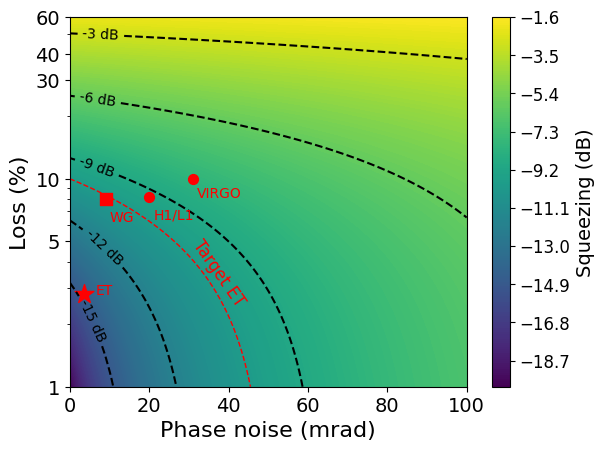

In [5]:
#Figure 1
def calculate_max_sqz(theta_rms,eta):
    '''This function calculates the maximum squeezing possible for a given efficiency and theta_rms.'''
    V_min = 2*eta*theta_rms*np.sqrt(1-theta_rms**2) + 1-eta
    return 10*np.log10(V_min) #Convert to dB

def contour_plot():
    theta_rms = np.linspace(0,100e-3,200) #Go from 0 to 200mrad
    loss = np.linspace(0.01,0.6,200)
    X,Y = np.meshgrid(theta_rms*1e3,loss*100)
    Z = np.zeros_like(X)
    for i in range(len(theta_rms)):
        for j in range(len(loss)):
            Z[j, i] = calculate_max_sqz(X[j, i]*1e-3, 1-Y[j, i]/100)
    plt.contourf(X,Y,Z,levels=200)
    plt.xlabel(r'Phase noise (mrad)',fontsize=16)
    plt.ylabel(r'Loss (%)',fontsize=16)
    #Add caption for the colourbar
    cbar = plt.colorbar()
    cbar.set_label('Squeezing (dB)', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    #Make y-axis logarithmic
    plt.yscale('log')
    plt.ylim(1,60)
    #Change y-ticks to go from 1 to 60 in multiplicative steps
    plt.yticks([1,5,10,30,40,60],['1','5','10','30','40','60'],fontsize=14)
    plt.xticks(fontsize=14)

    # Add specific curves for certain squeezing levels
    levels = [-15,-12,-9,-6,-3]
    contour_lines = plt.contour(X, Y, Z, levels=levels, colors='black', linestyles='dashed')


    plt.clabel(contour_lines, fmt='%2.0f dB', colors='black')

    #Add red stars at different loss and phase noise values to represent current and future squeezed light sources
    # plot stars and place text next to each star (no legend)
    points = [(9, 8, 'WG','s'),
              (20, 8.2, 'H1/L1','.'),
              (31, 10, 'VIRGO','.'),
              (3.5, 2.8, 'ET','*')]
    for x, y, txt, mark in points:
        if mark == 's':
            plt.scatter(x, y, color='red', marker=mark, s=80)
        else:
            plt.scatter(x, y, color='red', marker=mark, s=200)
        if txt == 'ET':
            plt.annotate(txt, xy=(x, y), xytext=(x + 3, y+0.1),
            color='red', fontsize=10, ha='left', va='center')
            continue
        plt.annotate(txt, xy=(x, y), xytext=(x + 1, y-1.5),
                     color='red', fontsize=10, ha='left', va='center')
    
    #Add a dashed red line at 10 dB showing the effective squeezing required for ET
    plt.contour(X, Y, Z, levels=[-10], colors='red', linestyles='dashed', linewidths=1)
    #Add text "10 dB required for ET" next to the line
    plt.text(30, 3.5, 'Target ET', color='red', fontsize=12, ha='left', va='center', rotation=-55)

    plt.show()
contour_plot()


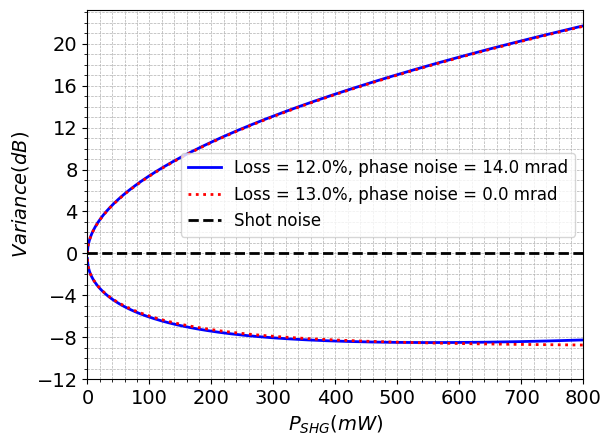

In [6]:
#Not included in paper, but shows the difficulty of separating phase noise and loss effects on squeezing measurements, since they can look very similar. Here we fit the squeezing vs input power curve to extract an effective loss, but the fit can be good even with significant phase noise present.
def plot_squeezing_input_power():
    alpha = 8.2
    P_in = np.linspace(0, 0.8, 1000)
    eta = 0.88  # 12 %loss
    theta_rms = 14e-3  # phase noise

    # Squeezing and anti-squeezing with phase noise and 12% loss
    sqz_phase_noise = variance(P_in, alpha, eta, np.pi/2,theta_rms)
    asqz_phase_noise = variance(P_in, alpha, eta, 0,theta_rms)
    label = 'Loss = ' + str(round((1-eta)*100,1)) + '%, phase noise = ' + str(round(theta_rms*1e3,1)) + ' mrad'
    plt.plot(P_in * 1e3, 10 * np.log10(sqz_phase_noise), color='blue', linewidth=2, label=label)
    plt.plot(P_in * 1e3, 10 * np.log10(asqz_phase_noise), color='blue', linewidth=2)

    def fit_variance(P_in, eta):
        return variance(P_in,alpha, eta, np.pi/2,0)

    popt, pcov = curve_fit(fit_variance, P_in, sqz_phase_noise)
    eta_fit = popt[0]
    #eta_fit = 0.914 #13% loss
    sqz_fit = variance(P_in,alpha, eta_fit,np.pi/2,0)
    label_fit = 'Loss = ' + str(round((1-eta_fit)*100,1)) + '%, phase noise = ' + str(round(0*1e3,1)) + ' mrad'
    plt.plot(P_in * 1e3, 10 * np.log10(sqz_fit), color='red', linewidth=2, linestyle=':', label=label_fit)
    asqz_fit = variance(P_in, alpha, eta_fit, 0,0)
    plt.plot(P_in * 1e3, 10 * np.log10(asqz_fit), color='red', linewidth=2, linestyle=':')
    #Mark shot noise level
    plt.axhline(0, color='black', linewidth=2, linestyle='--', label='Shot noise')

    plt.xlabel(r'$P_{SHG} (mW)$', fontsize=14)
    plt.ylabel(r'$Variance (dB)$', fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(np.arange(-12, 22, 4), fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(which='both', linestyle='--', linewidth=0.5)
    plt.minorticks_on()
    plt.xlim(0, 800)

plot_squeezing_input_power()
plt.show()

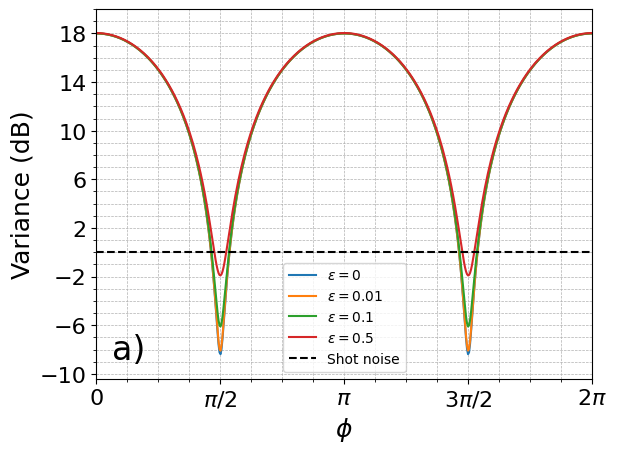

In [7]:
#Not included in paper
def leakage5050(theta,epsilon,sqz,asqz):
    #Defines the real leakage
    return asqz*np.cos(theta)**2 + sqz*np.sin(theta)**2 + epsilon

def plot_leakage5050(sqz,asqz):
    #Plot the real leakage vs the LO phase phi
    theta = np.linspace(0,2*np.pi,500)
    epsilon = [0,0.01,0.1,0.5]
    sqz = dB2power(-sqz)
    asqz = dB2power(asqz)
    #Now we are ready to plot
    plt.figure()
    for eps in epsilon:
        var = leakage5050(theta,eps,sqz,asqz)
        var = power2dB(var)
        plt.plot(theta,var,label=r'$\epsilon = $'+str(eps))

    #Mark shot noise level with dashed blacked line
    plt.axhline(y=0, color='black',label='Shot noise', linestyle='dashed')
    plt.xlabel(r'$\phi$',fontsize=18)
    plt.ylabel('Variance (dB)',fontsize=18)
    #Create x-ticks with 0 to 2*pi
    xticks = np.linspace(0,2*np.pi,5)
    plt.xticks(xticks, [r'$0$',r'$\pi/2$',r'$\pi$',r'$3\pi/2$',r'$2\pi$'])
    plt.xlim(0,2*np.pi)
    plt.ylim(power2dB(sqz)-2,power2dB(asqz)+2)
    plt.grid(which='both', linestyle='--', linewidth=0.5)
    plt.yticks(np.arange(-10,20,4),fontsize=16)
    plt.xticks(fontsize=16)
    #Add text box in bottom left corner which says a)
    plt.text(0.15, 0.15, 'a)', fontsize=24, transform=plt.gcf().transFigure)
    plt.minorticks_on()
    plt.legend()
    plt.show()

plot_leakage5050(8.4,18) #8.4 dB squeezing and 18 dB anti-squeezing are values from [1]

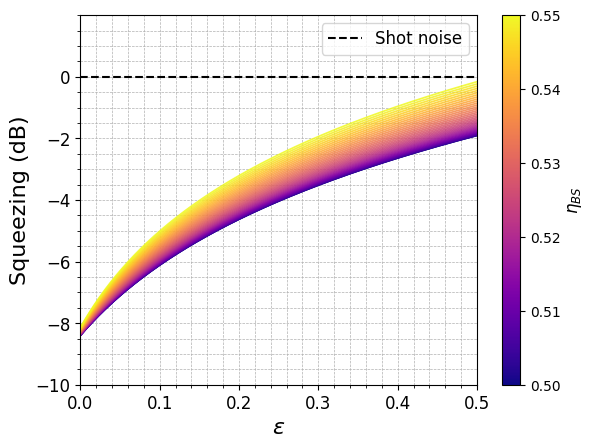

In [8]:
#Figure 4
def leakage_imperfect_BS(theta,epsilon,nBS,sqz,asqz):
    P_LO = 5e-3 #Power of the LO, does not matter since we divide by the vacuum fluctuations
    V_meas = P_LO*4*nBS*(1-nBS)*(asqz*np.cos(theta)**2 + sqz*np.sin(theta)**2 + epsilon)+P_LO*(2*nBS-1)**2*(1+epsilon*asqz) 
    + P_LO*2*np.sqrt(epsilon*nBS*(1-nBS))*(1-2*nBS)*np.cos(theta)*(1-asqz)
    V_vac = P_LO
    return V_meas/V_vac

def plot_sqz_vs_leakage_real(init_sqz,init_asqz):
    # Plot only the measured squeezing vs real leakage for different BS efficiencies

    sqz_lin = dB2power(-init_sqz)
    asqz_lin = dB2power(init_asqz)
    epsilon = np.linspace(0,0.5,500)

    plt.figure()
    # Create a color bundle showing a gradient of eta_BS from 0.50 to 0.55
    n_lines = 40
    eta_vals = np.linspace(0.50, 0.55, n_lines)
    cmap = plt.get_cmap('plasma')
    colors = [cmap(i/(n_lines-1)) for i in range(n_lines)]

    for idx, eta_BS in enumerate(eta_vals):
        measured = np.zeros_like(epsilon)
        for i, eps in enumerate(epsilon):
            measured[i] = leakage_imperfect_BS(np.pi/2, eps, eta_BS, sqz_lin, asqz_lin)
        plt.plot(epsilon, power2dB(measured), color=colors[idx], linewidth=1.25, alpha=0.85)

    # Add a colorbar to indicate the mapping between color and BS efficiency
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=eta_vals[0], vmax=eta_vals[-1]))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label(r'$\eta_{BS}$', fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    plt.axhline(y=0, color='black', label='Shot noise', linestyle='dashed')
    plt.xlim(0,0.5)
    plt.ylim(-10, 2)
    plt.xlabel(r'$\epsilon$', fontsize=16)
    plt.ylabel('Squeezing (dB)', fontsize=16)
    plt.xticks(np.arange(0,0.6,0.1), fontsize=12)
    plt.yticks(np.arange(-10,2,2), fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(which='both', linestyle='--', linewidth=0.5)
    plt.minorticks_on()
    plt.show()

plot_sqz_vs_leakage_real(8.4,18)

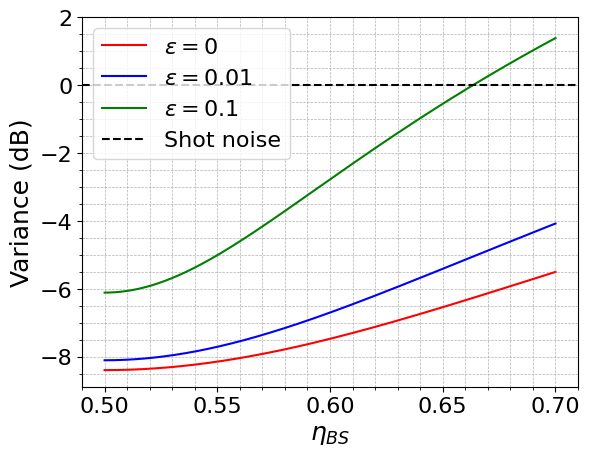

In [9]:
#Not included in paper
def plot_sqz_vs_BS_efficiency(init_sqz,init_asqz):
    #We wish to plot the squeezing vs the BS efficiency for different leakage levels
    init_sqz = dB2power(-init_sqz)
    init_asqz = dB2power(init_asqz)
    nBS = np.linspace(0.5,0.7,500)
    sqz = np.zeros(len(nBS))
    asqz = np.zeros(len(nBS))

    leakage_levels = [0,0.01,0.1]
    #Define the 3 colours we will use
    colors = ['red','blue','green']

    #Now we are ready to plot
    plt.figure()
    for j in range(len(leakage_levels)):
        for i in range(len(nBS)):
            sqz[i] = leakage_imperfect_BS(np.pi/2,leakage_levels[j],nBS[i],init_sqz,init_asqz)
            asqz[i] = leakage_imperfect_BS(0,leakage_levels[j],nBS[i],init_sqz,init_asqz)
        #plt.plot(nBS,power2dB(sqz),label=r'$Squeezing, \epsilon = $'+str(leakage_levels[j]),color = colors[j])
        #plt.plot(nBS,power2dB(asqz),label=r'$Anti-Squeezing, \epsilon = $'+str(leakage_levels[j]),color = colors[j])
        plt.plot(nBS,power2dB(sqz),label=r'$\epsilon = $'+str(leakage_levels[j]),color = colors[j])

    #Mark shot noise level with dashed blacked line
    plt.axhline(y=0, color='black',label='Shot noise', linestyle='dashed')
    plt.xlabel(r'$\eta_{BS}$',fontsize=18)
    plt.ylabel('Variance (dB)',fontsize=18)
    #plt.legend(bbox_to_anchor=(1.1, 1.05))
    plt.legend(fontsize="16")
    plt.yticks(np.arange(-8,4,2),fontsize=16)
    plt.xticks(np.arange(0.5,0.75,0.05),fontsize=16)
    plt.grid(which='both', linestyle='--', linewidth=0.5)
    plt.minorticks_on()
    plt.show()

plot_sqz_vs_BS_efficiency(8.4,18)


In [10]:
#Prepares equations for cascaded squeezers
def cascade_squeezer(M_lst,N_sqz,squeezing, params):
    '''Cascaded another squeezer, M_lst is the list of transfer functions, N_sqz is current the number of squeezer,
    returns new transfer functions and the new number of squeezers- Squeezing determines if amplitude squeezing is applied'''
    if N_sqz == 0:
        n1 = sp.Symbol('\eta_1',positive = True) #efficiency of the first squeezer
        R1 = sp.Symbol('R_1',real=True) #Squeezing parameter of first squeezer
        theta1 = sp.Symbol('\Theta_1',real=True)
        Rot = sp.Matrix([[sp.cos(theta1),sp.sin(theta1)],[-sp.sin(theta1),sp.cos(theta1)]])
        Rot_inv = sp.Matrix([[sp.cos(theta1),-sp.sin(theta1)],[sp.sin(theta1),sp.cos(theta1)]])
        params["n1"] = n1 #Add to dictionary
        params["R1"] = R1 #Add to dictionary
        params["theta1"] = theta1
        if squeezing: 
            M1 = sp.Matrix([[sp.sqrt(n1)*sp.exp(-R1), 0],[0,sp.sqrt(n1)*sp.exp(R1)]])
        else:
            M1 = sp.Matrix([[sp.sqrt(n1)*sp.exp(R1), 0],[0,sp.sqrt(n1)*sp.exp(-R1)]])
        L1 =  sp.Matrix([[sp.sqrt(1-n1), 0],[0,sp.sqrt(1-n1)]])
        M1 = Rot*M1*Rot_inv #Apply rotation matrix
        return [M1,L1],1
    n = sp.Symbol('\eta_'+str(N_sqz+1),positive = True) #efficiency of the squeezer
    R = sp.Symbol('R_'+str(N_sqz+1),real=True) #Squeezing parameter of squeezer
    theta = sp.Symbol('\Theta_'+str(N_sqz+1),real=True)
    Rot = sp.Matrix([[sp.cos(theta),sp.sin(theta)],[-sp.sin(theta),sp.cos(theta)]])
    Rot_inv = sp.Matrix([[sp.cos(theta),-sp.sin(theta)],[sp.sin(theta),sp.cos(theta)]])
    params["n" + str(N_sqz+1)] = n #Add to dictionary
    params["R" + str(N_sqz+1)] = R #Add to dictionary
    params["theta" + str(N_sqz+1)] = theta
    if squeezing:
        M = sp.Matrix([[sp.sqrt(n)*sp.exp(-R), 0],[0,sp.sqrt(n)*sp.exp(R)]])
    else:
        M = sp.Matrix([[sp.sqrt(n)*sp.exp(R), 0],[0,sp.sqrt(n)*sp.exp(-R)]])
    L = sp.Matrix([[sp.sqrt(1-n), 0],[0,sp.sqrt(1-n)]])
    for i in range(len(M_lst)):
        M_lst[i] = Rot*M*M_lst[i]*Rot_inv #Apply rotation matrix
    M_lst.append(L)
    return M_lst,N_sqz+1

def calculate_Vout(M_lst,params):
    '''Calculate the output variance of a given list of transfer functions, assumes only vacuum noise at the input'''
    V_out = sp.matrices.dense.matrix_multiply_elementwise(M_lst[-1],M_lst[-1])
    for i in range(len(M_lst)-1):
        V_out += sp.matrices.dense.matrix_multiply_elementwise(M_lst[i],M_lst[i])
    return V_out

def calculate_Veff(V_out,params):
    '''Calculate the effective detection efficiency of a given output variance'''
    V_amp_sqz = V_out[0,0] + V_out[0,1]
    V_amp_vac = V_amp_sqz.subs(params["R1"],0)
    V_eff = V_amp_sqz/V_amp_vac
    return V_eff

def lambdify_Veff(V_eff,params):
    '''Lambdify all parameters of V_eff'''
    #Change the symbols name to match the dictionary keys
    new_symbols = []
    for keys in params.keys():
        new_symbol = sp.Symbol(str(keys))
        new_symbols.append(new_symbol)
        V_eff = V_eff.subs(params[keys],new_symbol)
    return sp.lambdify(new_symbols,V_eff),new_symbols

params = {} #Dictionary of parameters
M_lst = []
N_sqz = 0
#Use two squeezers, first squeezing second anti-squeezing
M_lst,N_sqz = cascade_squeezer(M_lst,N_sqz,True,params)
M_lst,N_sqz = cascade_squeezer(M_lst,N_sqz,False,params)

V_out = calculate_Vout(M_lst,params)
V_eff = calculate_Veff(V_out,params) #Effective squeezing
lambdified_Veff,symbol_order = lambdify_Veff(V_eff,params)
print(symbol_order) #Note the symbol order


[n1, R1, theta1, n2, R2, theta2]


Initial squeezing:  -11.743155074642146


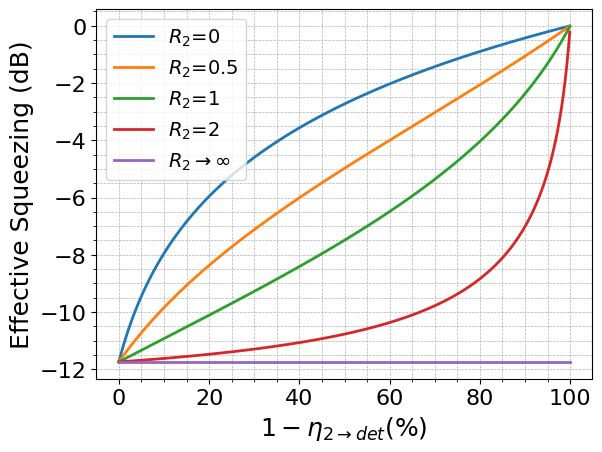

In [11]:

#Not included in paper
def plot_cascade_squeezers():
    #Plot squeezing vs outcoupling L_2
    # Parameters
    R1 = 2.1
    theta1 = 14e-3  # Assuming theta1 is constant for this plot
    n1 = 0.96
    theta2 = 0
    R2_values = [0, 0.5,1,2,100]  # Different values of R2

    def Veff_numerical(n1, R1, theta1, n2, R2, theta2):
        return power2dB(lambdified_Veff(n1,R1,theta1,n2,R2,theta2))

    # Generate data
    n2 = np.linspace(1e-3, 1, 1000)
    X = 1 - n2

    # Plot the data
    plt.figure()
    print("Initial squeezing: ", Veff_numerical(n1, R1, theta1, 1, 0, 0))
    for R2 in R2_values:
        Y = Veff_numerical(n1, R1, theta1, n2, R2, theta2)
        plt.plot(X*100, Y, label=r'$R_2$' + '=' + str(R2), linewidth=2)

    #Change the last legend label to be R_2 -> inf
    handles, labels = plt.gca().get_legend_handles_labels()
    labels[-1] = r'$R_2 \rightarrow \infty$'
    plt.legend(handles, labels,fontsize=14)

    plt.xlabel(r'$1-\eta_{2\rightarrow det}$' + '(%)', fontsize=18)
    plt.ylabel('Effective Squeezing (dB)', fontsize=18)
    plt.minorticks_on()
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(which='both', linestyle='--', linewidth=0.5)
    plt.show()

plot_cascade_squeezers()

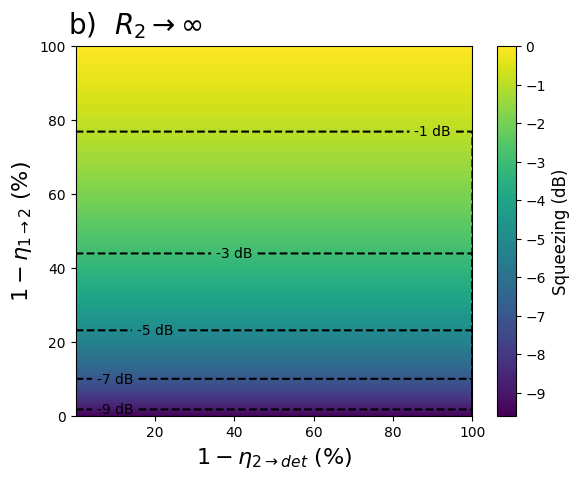

In [12]:
#Figure 6, a) and b)
def Veff_numerical(n1, R1, theta1, n2, R2, theta2):
    return power2dB(lambdified_Veff(n1,R1,theta1,n2,R2,theta2))

def plot_contour_eta_eta(R2):
    #We now wish to plot a contour plot with n1 as the y-axis and n2 as the x-axis
    # Parameters
    R1 = 1.1
    theta1 = 0
    theta2 = 0
    n1_values = np.linspace(0, 100, 100)
    n2_values = np.linspace(1e-3, 100, 10000)


    # Generate data
    X, Y = np.meshgrid(n2_values, n1_values)
    Z = Veff_numerical(1-Y/100, R1, theta1, 1-X/100, R2, theta2)

    # Plot the data
    plt.figure()
    plt.contourf(X, Y, Z, levels=200)
    cbar = plt.colorbar()
    cbar.set_label('Squeezing (dB)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    plt.xlabel(r'$1-\eta_{2\rightarrow det}$ (%)', fontsize=16)
    plt.ylabel(r'$1-\eta_{1 \rightarrow 2}$ (%)', fontsize=16)

    textstr = '\n'.join((
        r'b) ' + r' $R_2 \rightarrow \infty$',
        ))
    #If we want R2 -> inf, we can use the following textstr
    #textstr = '\n'.join((r'$c) R_2 \rightarrow \infty$',))
    plt.text(-0.02, 1.1, textstr, transform=plt.gca().transAxes, fontsize=20,
            verticalalignment='top')

    #Add specific curves for -1,-3,-5,-7 and -9 dB of squeezing
    #Make sure the labels are towards the middle of the plot
    levels = [-9,-7,-5,-3,-1]
    # Manually specify positions for the labels, be careful to not overlap
    manual_positions = [
        (90,90), (40, 40), (20, 20), (10,10), (10, 5)
    ]
    contour_lines = plt.contour(X, Y, Z, levels=levels, colors='black', linestyles='dashed')
    plt.clabel(contour_lines, fmt='%2.0f dB', colors='black', manual=manual_positions)

    # # Add red dash-dot contour showing the -3 dB contour for the case R2 = 0
    # Z_R2_0 = Veff_numerical(1-Y/100, R1, theta1, 1-X/100, 0, theta2)
    # hine = plt.contour(X, Y, Z_R2_0, levels=[-3], colors='red', linestyles='dashdot', linewidths=1)
    # plt.clabel(hine, fmt='-3 dB', colors='red', manual=[(20,20)])
    # plt.annotate(r'$R_2=0$', xy=(0.05, 0.45), xycoords='axes fraction', color='red', fontsize=14)

    plt.show()

plot_contour_eta_eta(1.1*200) #Change to choose R2 value

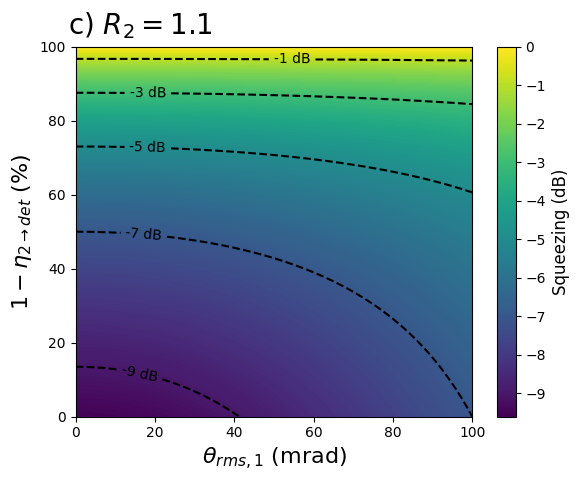

In [13]:
#Figure 6c
def plot_contour_eta_theta1(R2):
    #Make a contour plot of squeezing levels with 1-n2 on the y axis and theta1 on the x axis
    # n1, R1 and R2 is given. Now create a new function with n2, theta1 and theta 2 as the only variables
    n1 = 1
    R1 = 1.1
    theta2 = 0
    def new_Veff(theta1,n2):
        return power2dB(lambdified_Veff(n1,R1,theta1,n2,R2,theta2))
    
    textstr = '\n'.join((
        r'c)' + r' $R_2 = %.1f$' % R2,
        ))
    #If we want R2 -> inf, we can use the following textstr
    #textstr = '\n'.join((r'$c) R_2 \rightarrow \infty$',))
    plt.text(-0.02, 1.1, textstr, transform=plt.gca().transAxes, fontsize=20,
            verticalalignment='top')

    theta1 = np.linspace(0,100e-3,100) #Go from 0 to 100mrad
    n2 = np.linspace(0,1,100)
    X,Y = np.meshgrid(theta1*1e3,n2*100)
    Z = np.zeros_like(X)
    for i in range(len(theta1)):
        for j in range(len(n2)):
            Z[j, i] = new_Veff(X[j, i]*1e-3, 1-Y[j, i]/100)
    plt.contourf(X,Y,Z,levels=200)
    plt.xlabel(r'$\theta_{rms,1}$ (mrad)',fontsize=16)
    plt.ylabel(r'$1-\eta_{2\rightarrow det}$ (%)',fontsize=16)
    cbar = plt.colorbar()
    cbar.set_label('Squeezing (dB)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    #Create a textbox specifying the parameters n1,R1,R2,theta2
    textstr = '\n'.join((r'$\eta_1=%.2f$' % (round(n1*100), ) + ' %',
        r'$R_1=%.2f$' % (R1, ),
        r'$R_2=%.2f$' % (R2, ),
        r'$\theta_2=%.2f$' % (round(theta2*1e3), ) + ' mrad'))
    #plt.text(-0.4, 0.95, textstr, transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')

    # Add specific curves for -3, -5, -7, and -9 dB of squeezing
    levels = [-9,-7,-5,-3,-1]
    contour_lines = plt.contour(X, Y, Z, levels=levels, colors='black', linestyles='dashed')
    plt.clabel(contour_lines, fmt='%2.0f dB', colors='black')
    plt.show()

plot_contour_eta_theta1(1.1) #Change to choose R2 value

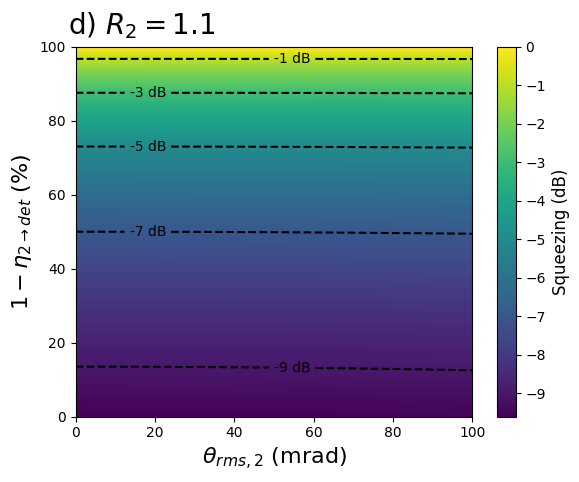

In [14]:
#Figure 6d
def plot_contour_eta_theta2():
    #Now we want the exact same graph, but with theta2 on the x axis instead of theta 1
    n1 = 1
    R1 = 1.1
    R2 = 1.1
    theta1 = 0
    def new_Veff(theta2,n2):
        return power2dB(lambdified_Veff(n1,R1,theta1,n2,R2,theta2))

    textstr = '\n'.join((
        r'd)' + r' $R_2 = %.1f$' % R2,
        ))
    #If we want R2 -> inf, we can use the following textstr
    #textstr = '\n'.join((r'$c) R_2 \rightarrow \infty$',))
    plt.text(-0.02, 1.1, textstr, transform=plt.gca().transAxes, fontsize=20,
            verticalalignment='top')

    theta2 = np.linspace(0,100e-3,100) #Go from 0 to 100mrad
    n2 = np.linspace(0,1,100)
    X,Y = np.meshgrid(theta2*1e3,n2*100)
    Z = np.zeros_like(X)
    for i in range(len(theta2)):
        for j in range(len(n2)):
            Z[j, i] = new_Veff(X[j, i]*1e-3, 1-Y[j, i]/100)
    plt.contourf(X,Y,Z,levels=200)
    plt.xlabel(r'$\theta_{rms,2}$ (mrad)',fontsize=16)
    plt.ylabel(r'$1-\eta_{2\rightarrow det}$ (%)',fontsize=16)
    cbar = plt.colorbar()
    cbar.set_label('Squeezing (dB)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    #Create a textbox specifying the parameters n1,R1,R2,theta2
    textstr = '\n'.join((
        r'$\eta_1=%.2f$' % (round(n1*100), ) + ' %',
        r'$R_1=%.2f$' % (R1, ),
        r'$R_2=%.2f$' % (R2, ),
        r'$\theta_1=%.2f$' % (round(theta1*1e3), ) + ' mrad'))
    #plt.text(-0.4, 0.95, textstr, transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')

    # Add specific curves for -3, -5, -7, and -9 dB of squeezing
    levels = [-9,-7,-5,-3,-1]
    contour_lines = plt.contour(X, Y, Z, levels=levels, colors='black', linestyles='dashed')
    plt.clabel(contour_lines, fmt='%2.0f dB', colors='black')
    plt.show()

plot_contour_eta_theta2()